In [2]:
import pandas as pd
from matplotlib import pyplot as plt
import statsmodels.api as sm
from influxdb import DataFrameClient

In [1]:
plt.rcParams['figure.figsize'] = [20, 15]

NameError: name 'plt' is not defined

In [10]:
host = 'influxdb'
port = 8086
user = 'root'
password = 'root'
dbname = 'VirtualBuilding'
client = DataFrameClient(host, port, user, password, dbname)

In [11]:
tmp=client.query('select * from Temperature')
print(tmp)
tmp['Temperature']

defaultdict(<class 'list'>, {'Temperature':                                   location  node     value
2013-11-28 12:51:19+00:00  VirtualBuilding  T_ex   8.00000
2013-11-28 12:51:19+00:00  VirtualBuilding  T_in  24.34512
2013-11-28 13:25:32+00:00  VirtualBuilding  T_ex   8.00000
2013-11-28 13:25:32+00:00  VirtualBuilding  T_in  24.31374
2013-11-28 13:33:08+00:00  VirtualBuilding  T_ex   8.00000
...                                    ...   ...       ...
2014-04-21 01:57:33+00:00  VirtualBuilding  T_in  18.25882
2014-04-21 02:03:36+00:00  VirtualBuilding  T_ex  13.00000
2014-04-21 02:03:36+00:00  VirtualBuilding  T_in  18.25882
2014-04-21 02:09:38+00:00  VirtualBuilding  T_ex  13.00000
2014-04-21 02:09:38+00:00  VirtualBuilding  T_in  18.25882

[4757 rows x 3 columns]})


,location,node,value
2013-11-28 12:51:19+00:00,VirtualBuilding,T_ex,8.00000
2013-11-28 12:51:19+00:00,VirtualBuilding,T_in,24.34512
2013-11-28 13:25:32+00:00,VirtualBuilding,T_ex,8.00000
2013-11-28 13:25:32+00:00,VirtualBuilding,T_in,24.31374
2013-11-28 13:33:08+00:00,VirtualBuilding,T_ex,8.00000
...,...,...,...
2014-04-21 01:57:33+00:00,VirtualBuilding,T_in,18.25882
2014-04-21 02:03:36+00:00,VirtualBuilding,T_ex,13.00000
2014-04-21 02:03:36+00:00,VirtualBuilding,T_in,18.25882
2014-04-21 02:09:38+00:00,VirtualBuilding,T_ex,13.00000


In [12]:
tmp = tmp['Temperature'].pivot(columns='node',values='value')
tmp

node,T_ex,T_in
2013-11-28 12:51:19+00:00,8.0,24.34512
2013-11-28 13:25:32+00:00,8.0,24.31374
2013-11-28 13:33:08+00:00,8.0,24.28236
2013-11-28 13:44:06+00:00,8.0,24.34510
2013-11-28 13:48:22+00:00,8.0,24.34510
...,...,...
2014-04-21 01:45:27+00:00,13.0,18.29020
2014-04-21 01:51:29+00:00,13.0,18.25882
2014-04-21 01:57:33+00:00,13.0,18.25882
2014-04-21 02:03:36+00:00,13.0,18.25882


In [13]:
df=pd.DataFrame(tmp.T_ex)
df['T_in']=tmp.T_in

In [14]:
df.head()

,T_ex,T_in
2013-11-28 12:51:19+00:00,8.0,24.34512
2013-11-28 13:25:32+00:00,8.0,24.31374
2013-11-28 13:33:08+00:00,8.0,24.28236
2013-11-28 13:44:06+00:00,8.0,24.34510
2013-11-28 13:48:22+00:00,8.0,24.34510


In [16]:
tmp=client.query('select * from Power')
tmp=tmp['Power'].pivot(columns='node',values='value') 
tmp

node,Power
2013-11-28 12:51:19+00:00,26.718750
2013-11-28 13:25:32+00:00,26.830357
2013-11-28 13:33:08+00:00,26.316964
2013-11-28 13:44:06+00:00,26.651786
2013-11-28 13:48:22+00:00,26.250000
...,...
2014-04-21 01:39:23+00:00,0.000000
2014-04-21 01:45:27+00:00,0.000000
2014-04-21 01:51:29+00:00,0.000000
2014-04-21 01:57:33+00:00,0.000000


In [17]:
df['Power']=tmp['Power']
df.head()

,T_ex,T_in,Power
2013-11-28 12:51:19+00:00,8.0,24.34512,26.718750
2013-11-28 13:25:32+00:00,8.0,24.31374,26.830357
2013-11-28 13:33:08+00:00,8.0,24.28236,26.316964
2013-11-28 13:44:06+00:00,8.0,24.34510,26.651786
2013-11-28 13:48:22+00:00,8.0,24.34510,26.250000


In [18]:
df['deltaT']=df.T_in-df.T_ex
df.head()

,T_ex,T_in,Power,deltaT
2013-11-28 12:51:19+00:00,8.0,24.34512,26.718750,16.34512
2013-11-28 13:25:32+00:00,8.0,24.31374,26.830357,16.31374
2013-11-28 13:33:08+00:00,8.0,24.28236,26.316964,16.28236
2013-11-28 13:44:06+00:00,8.0,24.34510,26.651786,16.34510
2013-11-28 13:48:22+00:00,8.0,24.34510,26.250000,16.34510


In [19]:
df=df.dropna()

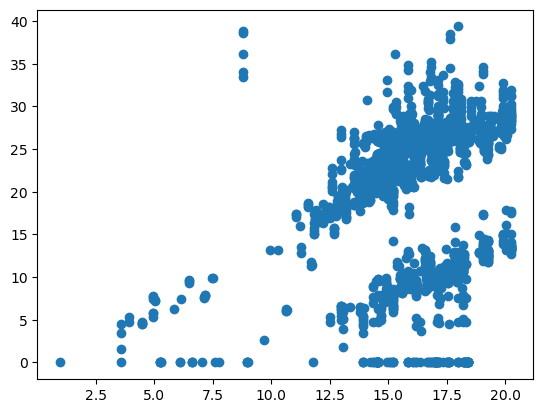

In [20]:
plt.scatter(df.deltaT,df.Power)

In [21]:
model = sm.OLS(df.Power,sm.add_constant(df.deltaT))

In [22]:
results=model.fit()

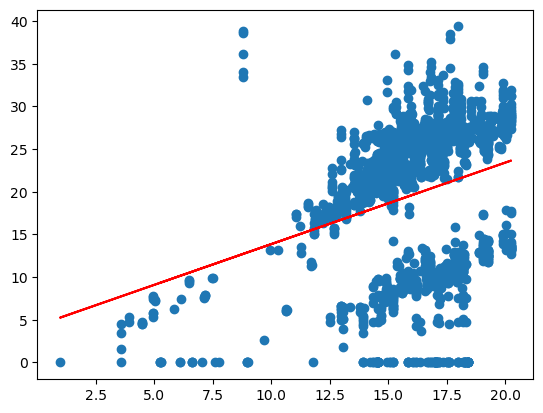

In [23]:
plt.plot(df.deltaT,results.predict(),'r')
plt.scatter(df.deltaT,df.Power)

In [24]:
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Power   R-squared:                       0.083
Model:                            OLS   Adj. R-squared:                  0.082
Method:                 Least Squares   F-statistic:                     183.6
Date:                Thu, 28 Nov 2024   Prob (F-statistic):           4.02e-40
Time:                        16:20:47   Log-Likelihood:                -7188.2
No. Observations:                2042   AIC:                         1.438e+04
Df Residuals:                    2040   BIC:                         1.439e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.3218      1.154      3.745      0.000       2.059       6.585
deltaT         0.9546      0.070     13.551      0.000       0.816       1.093
==============================================================================
Omnibus:                      181.502   Durbin-Watson:                   0.396
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              230.798
Skew:                          -0.819   Prob(JB):                     7.64e-51
Kurtosis:                       2.832   Cond. No.                         105.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [25]:
df=df.resample('H').mean()
df=df.dropna()

/tmp/ipykernel_70674/836416887.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df=df.resample('H').mean()


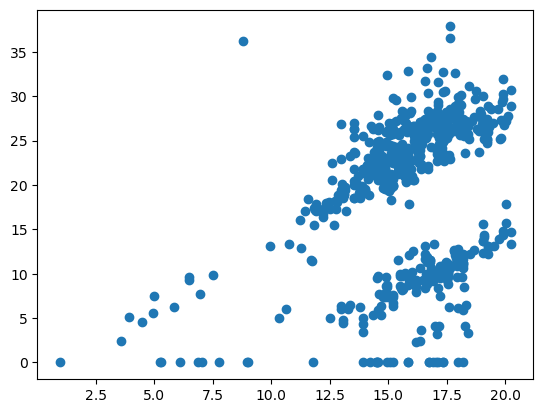

In [26]:
plt.scatter(df.deltaT,df.Power)

In [27]:
model = sm.OLS(df.Power,sm.add_constant(df.deltaT))

In [28]:
results=model.fit()

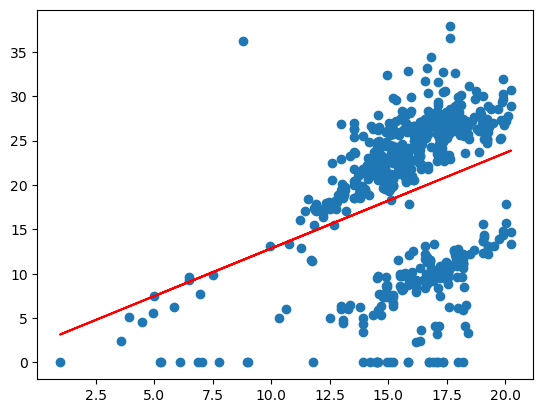

In [29]:
plt.plot(df.deltaT,results.predict(),'r')
plt.scatter(df.deltaT,df.Power)

In [30]:
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Power   R-squared:                       0.108
Model:                            OLS   Adj. R-squared:                  0.107
Method:                 Least Squares   F-statistic:                     77.56
Date:                Thu, 28 Nov 2024   Prob (F-statistic):           1.21e-17
Time:                        16:21:28   Log-Likelihood:                -2246.4
No. Observations:                 640   AIC:                             4497.
Df Residuals:                     638   BIC:                             4506.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.1034      1.963      1.071      0.284      -1.752       5.958
deltaT         1.0749      0.122      8.807      0.000       0.835       1.315
==============================================================================
Omnibus:                       58.338   Durbin-Watson:                   1.184
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               63.213
Skew:                          -0.729   Prob(JB):                     1.88e-14
Kurtosis:                       2.503   Cond. No.                         98.9
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [31]:
df=df.resample('D').mean()
df=df.dropna()

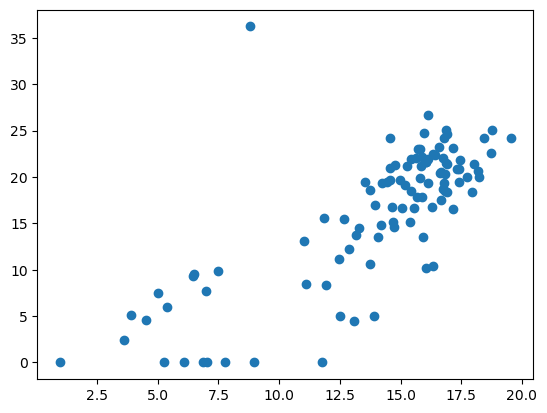

In [32]:
plt.scatter(df.deltaT,df.Power)

In [33]:
model = sm.OLS(df.Power,sm.add_constant(df.deltaT))

In [34]:
results=model.fit()

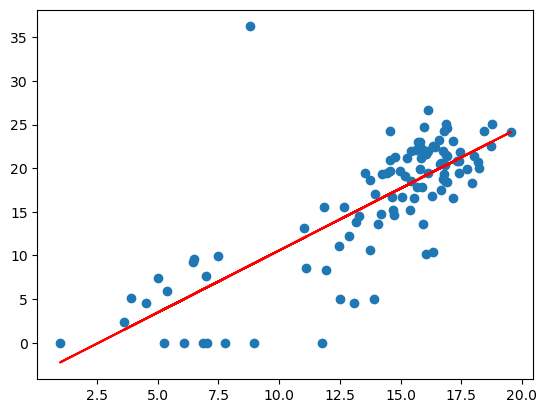

In [35]:
plt.plot(df.deltaT,results.predict(),'r')
plt.scatter(df.deltaT,df.Power)

In [36]:
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Power   R-squared:                       0.584
Model:                            OLS   Adj. R-squared:                  0.580
Method:                 Least Squares   F-statistic:                     141.9
Date:                Thu, 28 Nov 2024   Prob (F-statistic):           5.82e-21
Time:                        16:21:55   Log-Likelihood:                -307.96
No. Observations:                 103   AIC:                             619.9
Df Residuals:                     101   BIC:                             625.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.6429      1.737     -2.097      0.038      -7.089      -0.197
deltaT         1.4216      0.119     11.913      0.000       1.185       1.658
==============================================================================
Omnibus:                       46.374   Durbin-Watson:                   1.994
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              372.941
Skew:                           1.140   Prob(JB):                     1.04e-81
Kurtosis:                      12.039   Cond. No.                         53.1
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [37]:
df=df.resample('W').mean()
df=df.dropna()

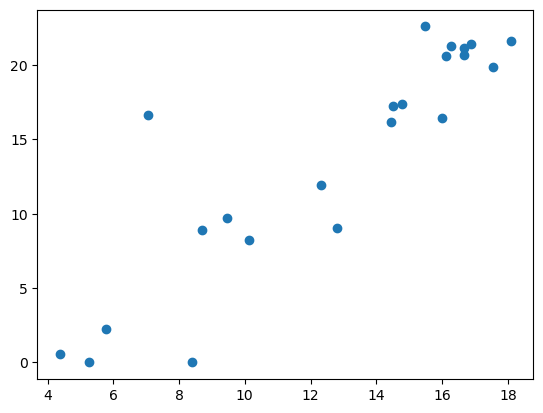

In [38]:
plt.scatter(df.deltaT,df.Power)


In [39]:
model = sm.OLS(df.Power,sm.add_constant(df.deltaT))

In [40]:
results=model.fit()

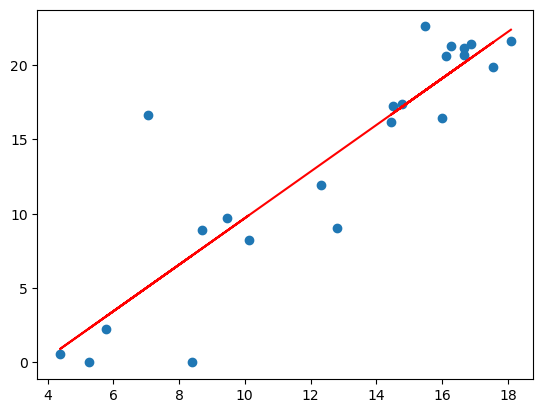

In [41]:
plt.plot(df.deltaT,results.predict(),'r')
plt.scatter(df.deltaT,df.Power)

In [42]:
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Power   R-squared:                       0.796
Model:                            OLS   Adj. R-squared:                  0.786
Method:                 Least Squares   F-statistic:                     77.91
Date:                Thu, 28 Nov 2024   Prob (F-statistic):           2.47e-08
Time:                        16:22:20   Log-Likelihood:                -58.341
No. Observations:                  22   AIC:                             120.7
Df Residuals:                      20   BIC:                             122.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -5.9502      2.367     -2.514      0.021     -10.887      -1.014
deltaT         1.5654      0.177      8.827      0.000       1.195       1.935
==============================================================================
Omnibus:                       15.225   Durbin-Watson:                   1.968
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               20.155
Skew:                           1.216   Prob(JB):                     4.20e-05
Kurtosis:                       7.009   Cond. No.                         41.4
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""